In [1]:
import cv2

In [2]:
image = cv2.imread("images/flowers.jpg")

In [3]:
image                                 #numpy array of uint8 type and shape (1718, 2482, 3) (rows, cols, channels)

array([[[252, 252, 252],
        [255, 255, 255],
        [251, 251, 251],
        ...,
        [255, 255, 247],
        [255, 255, 255],
        [255, 255, 255]],

       [[242, 242, 242],
        [251, 251, 251],
        [250, 250, 250],
        ...,
        [255, 255, 248],
        [255, 255, 255],
        [255, 255, 255]],

       [[254, 254, 254],
        [243, 243, 243],
        [249, 249, 249],
        ...,
        [255, 255, 249],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [248, 248, 248],
        ...,
        [232, 245, 243],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [244, 244, 244],
        ...,
        [239, 252, 250],
        [255, 255, 255],
        [255, 255, 255]],

       [[247, 247, 247],
        [245, 245, 245],
        [255, 255, 255],
        ...,
        [248, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [4]:
image[0][0]      #rgb for the first pixel

array([252, 252, 252], dtype=uint8)

In [5]:
cv2.imshow('image', image)      #window name and object name, default color space: RGB. But stores in BGR order
cv2.waitKey(0)                  #time to wait before closing the image. Here, 0 = loop forever for manual close
cv2.destroyAllWindows()         #close windows automatically after WaitKey time is over

In [6]:
import matplotlib.pyplot as plt

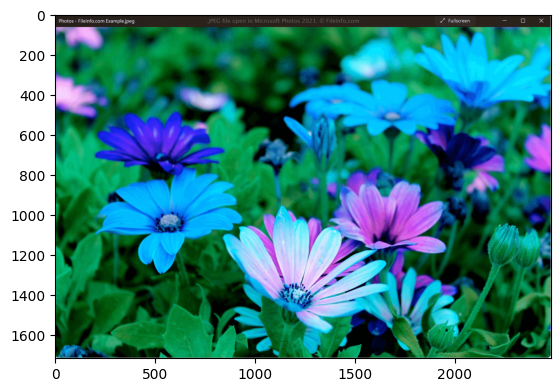

In [7]:
plt.imshow(image)                           #use matplotlib to show image directly in notebook, uses RGB order
                                            #here, it confuses openCV's BGR order. interchanging REDs and BLUEs

In [8]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)       #converting BGR to RGB for Matplotlib show

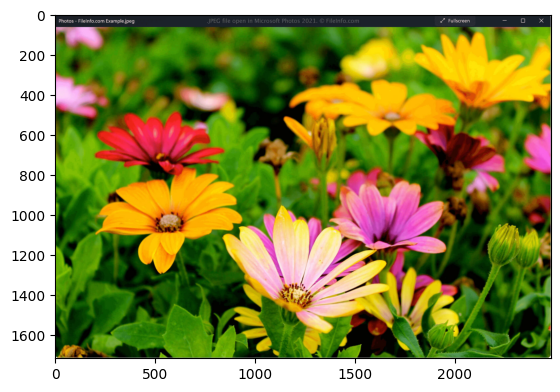

In [9]:
plt.imshow(image_rgb)    

In [10]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)    #convert to grayscale 

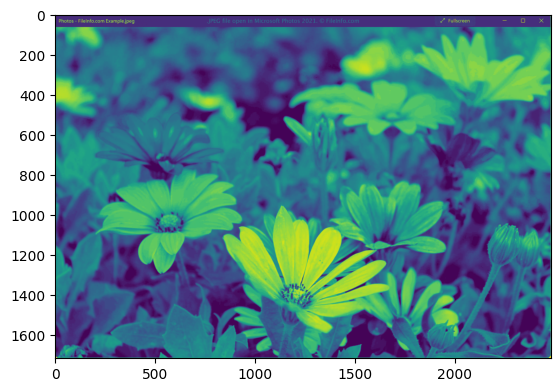

In [11]:
plt.imshow(image_gray)         #matplotlib doesn't show grayscale. Use OpenCV

In [12]:
cv2.imshow('image', image_gray)
cv2.waitKey(0)                  
cv2.destroyAllWindows()

In [13]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [14]:
cv2.imshow('image', image_hsv)
cv2.waitKey(0)                  
cv2.destroyAllWindows()

In [15]:
cv2.imshow('image', image)
cv2.waitKey(0)                  
cv2.destroyAllWindows()

In [16]:
hue, sat, val = cv2.split(image_hsv)

In [17]:
add_val = +50

In [18]:
val 

array([[252, 255, 251, ..., 255, 255, 255],
       [242, 251, 250, ..., 255, 255, 255],
       [254, 243, 249, ..., 255, 255, 255],
       ...,
       [255, 255, 248, ..., 245, 255, 255],
       [255, 255, 244, ..., 252, 255, 255],
       [247, 245, 255, ..., 255, 255, 255]],
      shape=(1718, 2482), dtype=uint8)

In [19]:
val + 50           #goes 256 -> 0, 257 -> 1,.... because type = uint8

array([[46, 49, 45, ..., 49, 49, 49],
       [36, 45, 44, ..., 49, 49, 49],
       [48, 37, 43, ..., 49, 49, 49],
       ...,
       [49, 49, 42, ..., 39, 49, 49],
       [49, 49, 38, ..., 46, 49, 49],
       [41, 39, 49, ..., 49, 49, 49]], shape=(1718, 2482), dtype=uint8)

In [20]:
import numpy as np

In [21]:
new_val = val.astype(np.int64) + add_val       #allow values to not go back to 0,1,... and cap those exceeding 255
new_val[new_val>255] = 255  #to decrease brightness, use negative add_val with the condition new_val[new_val] > 255 = 255

In [22]:
new_val

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(1718, 2482))

In [23]:
new_val_uint8 = new_val.astype(np.uint8)    #convert back to uint8 as that's what OpenCV expects

In [24]:
new_val_uint8

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(1718, 2482), dtype=uint8)

In [25]:
image_new_hsv = cv2.merge([hue, sat, new_val_uint8])

In [26]:
image_new_bgr = cv2.cvtColor(image_new_hsv, cv2.COLOR_HSV2BGR)

In [27]:
image_new_bgr

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 247],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 248],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 249],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [241, 255, 253],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [242, 255, 253],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [248, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [28]:
cv2.imshow('image', image_new_bgr)
cv2.waitKey(0)                  
cv2.destroyAllWindows()

In [29]:
#all merged into one function
def changeBrightness(image, add_val): 
    image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 
    hue, sat, val = cv2.split(image_hsv)
    
    new_val = val.astype(np.int64) + add_val
    new_val[new_val>255] = 255
    
    new_val_uint8 = new_val.astype(np.uint8)
    
    image_new_hsv = cv2.merge([hue, sat, new_val_uint8])
    image_new_bgr = cv2.cvtColor(image_new_hsv, cv2.COLOR_HSV2BGR)
    return image_new_bgr

In [30]:
changeBrightness(image, 1000)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 247],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 248],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 249],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [241, 255, 253],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [242, 255, 253],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [248, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [31]:
cv2.imshow('image', changeBrightness(image, 1000))
cv2.waitKey(0)                  
cv2.destroyAllWindows()

In [39]:
image_grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)       #convert to grey for Sobel filter

In [40]:
image_grey

array([[252, 255, 251, ..., 253, 255, 255],
       [242, 251, 250, ..., 253, 255, 255],
       [254, 243, 249, ..., 253, 255, 255],
       ...,
       [255, 255, 248, ..., 243, 255, 255],
       [255, 255, 244, ..., 250, 255, 255],
       [247, 245, 255, ..., 254, 255, 255]],
      shape=(1718, 2482), dtype=uint8)

In [41]:
cv2.imshow('image', image_grey)
cv2.waitKey(0)                  
cv2.destroyAllWindows()

In [46]:
sobel_x = cv2.Sobel(image_grey, ddepth=cv2.CV_64F, dx=1, dy=0)        #applying Sobel filter algorithm
sobel_y = cv2.Sobel(image_grey, ddepth=cv2.CV_64F, dx=0, dy=1)        #applying Sobel filter algorithm
sobel_xy = cv2.Sobel(image_grey, ddepth=cv2.CV_64F, dx=1, dy=1)        #applying Sobel filter algorithm

In [49]:
cv2.imshow('image', sobel_xy)
cv2.waitKey(0)                  
cv2.destroyAllWindows()